# Data Cleaning for Online Retail Customer Segmentation

This notebook prepares the Online Retail transaction data for the next stage of the dissertation: RFM feature engineering and K-Means customer segmentation.



The raw dataframe is kept unchanged in `df_original`, while all cleaning is carried out on a copy called `df`. Tables, figures and the final cleaned dataset are saved in separate folders inside `Results`.

**Before running:** upload `Online Retail.xlsx` to the Colab `/content/` folder, then run the notebook from top to bottom.

## 1. Import libraries and prepare output folders

It loads the Python libraries used for data handling, numerical calculations and visualisation. It also creates separate folders for figures, tables and cleaned data. Pandas and NumPy are used for data processing, while Matplotlib and Seaborn are used for charts. Display settings are adjusted so that tables are easier to inspect in Colab.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")



**Creating project folders to store results**

In [2]:
results_dir = "Results"
figures_dir = os.path.join(results_dir, "Figures")
tables_dir = os.path.join(results_dir, "Tables")
data_dir = os.path.join(results_dir, "Data")

os.makedirs(results_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)

## 2. Loading the original dataset

Tghis reads the Excel file and creates a separate working copy. Keeping `df_original` unchanged makes it possible to compare the cleaned dataset with the source data later.


In [3]:
df_original = pd.read_excel("/content/Online Retail.xlsx")
df = df_original.copy()

original_rows = len(df)

print("Dataset loaded successfully")
print("Original shape:", df.shape)


Dataset loaded successfully
Original shape: (541909, 8)


## 3. Understanding the structure of the raw data
Before removing any records, I am going to inspect the dataset to understand its columns, data types and value ranges.It displays the first rows, last rows and a random sample. It then shows column information, numerical statistics and categorical statistics.


In [4]:
display(df.head())
display(df.tail())
display(df.sample(5, random_state=42))

print("\nDataset Info")
df.info()

print("\nNumerical Summary")
display(df.describe())

print("\nCategorical Summary")
display(df.describe(include="object"))


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
209268,555200,71459,HANGING JAM JAR T-LIGHT HOLDER,24,2011-06-01 12:05:00,0.85,17315.0,United Kingdom
207108,554974,21128,GOLD FISHING GNOME,4,2011-05-27 17:14:00,6.95,14031.0,United Kingdom
167085,550972,21086,SET/6 RED SPOTTY PAPER CUPS,4,2011-04-21 17:05:00,0.65,14031.0,United Kingdom
471836,576652,22812,PACK 3 BOXES CHRISTMAS PANETTONE,3,2011-11-16 10:39:00,1.95,17198.0,United Kingdom
115865,546157,22180,RETROSPOT LAMP,2,2011-03-10 08:40:00,9.95,13502.0,United Kingdom



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Numerical Summary


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303



Categorical Summary


,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


## 4.  initial data-quality report
It provides a baseline view of missing data before any cleaning is performed like the missing count, missing percentage, number of unique values and data type then i am going to show two visualisations: a missing-value heatmap and a bar chart of missing percentages.


,Column,Missing Count,Missing Percentage (%),Unique Values,Data Type
0,InvoiceNo,0,0.00,25900,object
1,StockCode,0,0.00,4070,object
2,Description,1454,0.27,4223,object
3,Quantity,0,0.00,722,int64
4,InvoiceDate,0,0.00,23260,datetime64[ns]
5,UnitPrice,0,0.00,1630,float64
6,CustomerID,135080,24.93,4372,float64
7,Country,0,0.00,38,object


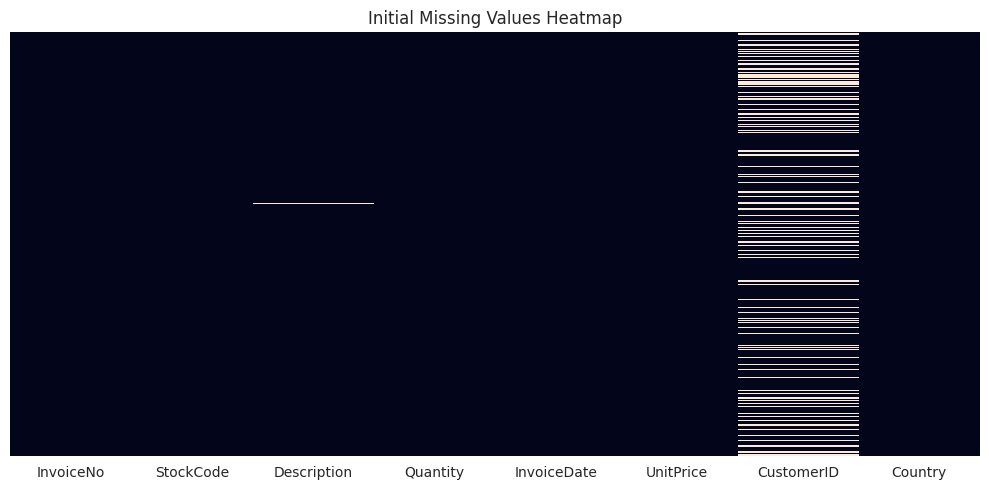

<Figure size 1000x500 with 0 Axes>

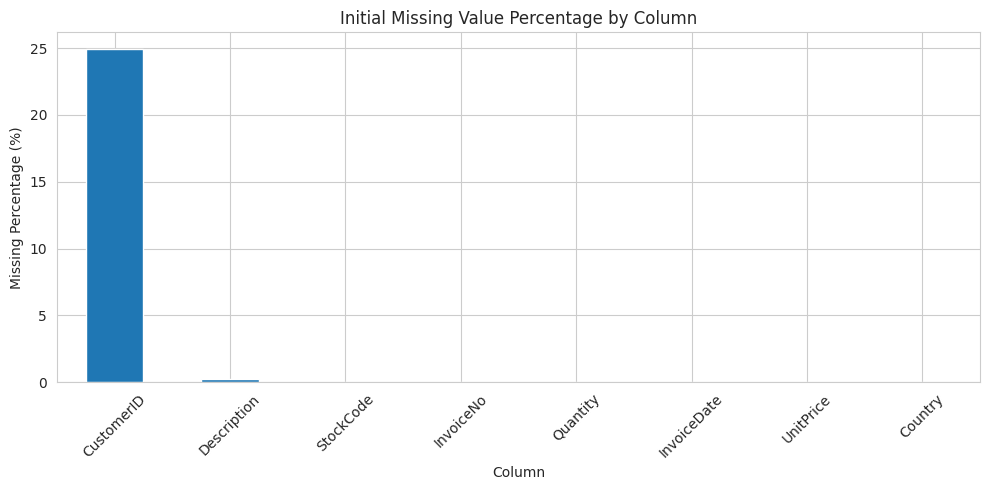

In [5]:
missing_report_initial = pd.DataFrame({
    "Column": df.columns,
    "Missing Count": df.isnull().sum().values,
    "Missing Percentage (%)": (df.isnull().mean() * 100).round(2).values,
    "Unique Values": [df[col].nunique() for col in df.columns],
    "Data Type": df.dtypes.astype(str).values
})

display(missing_report_initial)

missing_report_initial.to_csv(
    os.path.join(tables_dir, "initial_missing_value_report.csv"),
    index=False
)
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Initial Missing Values Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "initial_missing_values_heatmap.png"), dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
missing_report_initial.sort_values("Missing Percentage (%)", ascending=False).plot(
    x="Column",
    y="Missing Percentage (%)",
    kind="bar",
    legend=False,
    figsize=(10, 5)
)
plt.title("Initial Missing Value Percentage by Column")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "initial_missing_value_percentage.png"), dpi=300)
plt.show()


## 5. Create a cleaning log and remove exact duplicates

It records how many rows are removed at each cleaning step.


In [6]:
cleaning_log = []

def log_step(step, before_rows, after_rows):
    cleaning_log.append({
        "Cleaning Step": step,
        "Rows Before": before_rows,
        "Rows After": after_rows,
        "Rows Removed": before_rows - after_rows
    })

# Duplicate


duplicate_count = df.duplicated().sum()

print("Duplicate rows found:", duplicate_count)

if duplicate_count > 0:
    display(df[df.duplicated()].head())

before = len(df)
df = df.drop_duplicates()
after = len(df)

log_step("Duplicate records removed", before, after)


Duplicate rows found: 5268


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom


## 6. Correction of the date field and handling missing customer identifiers


In [7]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

print("InvoiceDate converted to datetime")
print("Missing InvoiceDate values:", df["InvoiceDate"].isnull().sum())

# Missing Customer id
missing_customer = df["CustomerID"].isnull().sum()
print("Missing CustomerID records:", missing_customer)

if missing_customer > 0:
    display(df[df["CustomerID"].isnull()].head())
before = len(df)
df = df.dropna(subset=["CustomerID"])
after = len(df)
log_step("Missing CustomerID records removed", before, after)

missing_description = df["Description"].isnull().sum()

print("Missing Description records after CustomerID removal:", missing_description)

if missing_description > 0:
    missing_description_rows = df[df["Description"].isnull()]
    display(missing_description_rows.head())

    description_investigation = missing_description_rows[[
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "UnitPrice",
        "CustomerID",
        "Country"
    ]]

    display(description_investigation.head())

    description_investigation.to_csv(
        os.path.join(tables_dir, "missing_description_investigation.csv"),
        index=False
    )


InvoiceDate converted to datetime
Missing InvoiceDate values: 0
Missing CustomerID records: 135037


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom


Missing Description records after CustomerID removal: 0


## 7. Investigate adjustment and cancelled invoices

Customer segmentation should be based on completed purchases. Invoice numbers beginning with `A` are checked as adjustment records, while numbers beginning with `C` represent cancellations or returns and the excluded records are inspected and saved as separate CSV files before being removed


In [8]:
adjustment_rows = df[df["InvoiceNo"].astype(str).str.startswith("A")]

print("Adjustment invoice records found:", len(adjustment_rows))

if len(adjustment_rows) > 0:
    display(adjustment_rows.head())

    adjustment_rows.to_csv(
        os.path.join(tables_dir, "adjustment_invoice_records.csv"),
        index=False
    )

before = len(df)
df = df[~df["InvoiceNo"].astype(str).str.startswith("A")]
after = len(df)

log_step("Adjustment invoice records removed", before, after)

# INVESTIGATE AND REMOVE CANCELLED INVOICES

cancelled_rows = df[df["InvoiceNo"].astype(str).str.startswith("C")]

print("Cancelled invoice records found:", len(cancelled_rows))

if len(cancelled_rows) > 0:
    display(cancelled_rows.head())

    cancelled_rows.to_csv(
        os.path.join(tables_dir, "cancelled_invoice_records.csv"),
        index=False
    )

before = len(df)
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
after = len(df)

log_step("Cancelled invoice records removed", before, after)


Adjustment invoice records found: 0
Cancelled invoice records found: 8872


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


The current run contains no `A` adjustment invoices after the earlier filtering, but it contains 8,872 cancelled invoice rows. A sample of the cancelled records is displayed.

## 8. Remove non-positive quantity and price records

This block checks for quantities less than or equal to zero and prices less than or equal to zero. Any affected rows are saved for reference and then removed, with the row changes added to the cleaning log.


In [9]:
invalid_quantity_rows = df[df["Quantity"] <= 0]

print("Invalid quantity records found:", len(invalid_quantity_rows))

if len(invalid_quantity_rows) > 0:
    display(invalid_quantity_rows.head())

    invalid_quantity_rows.to_csv(
        os.path.join(tables_dir, "invalid_quantity_records.csv"),
        index=False
    )

before = len(df)
df = df[df["Quantity"] > 0]
after = len(df)

log_step("Invalid quantity records removed", before, after)

# REMOVE INVALID UNIT PRICE VALUES

invalid_price_rows = df[df["UnitPrice"] <= 0]

print("Invalid UnitPrice records found:", len(invalid_price_rows))

if len(invalid_price_rows) > 0:
    display(invalid_price_rows.head())

    invalid_price_rows.to_csv(
        os.path.join(tables_dir, "invalid_unitprice_records.csv"),
        index=False
    )

before = len(df)
df = df[df["UnitPrice"] > 0]
after = len(df)

log_step("Invalid UnitPrice records removed", before, after)


Invalid quantity records found: 0
Invalid UnitPrice records found: 40


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom


## 9. Standardise data types and calculate transaction value
Customer IDs are converted to integers, identifier fields are stored as strings, and `TotalAmount` is calculated as `Quantity × UnitPrice`.

The output lists the final data types and displays a few rows showing the quantity, unit price and calculated total amount.


In [10]:
df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df["StockCode"] = df["StockCode"].astype(str)
df["Country"] = df["Country"].astype(str)

print("Final data types")
display(df.dtypes)

#  CREATE TOTAL AMOUNT

df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

display(df[["Quantity", "UnitPrice", "TotalAmount"]].head())


Final data types


,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,int64
Country,object


,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## 10. Validating the cleaning rules and summarise removed records




In [11]:
validation_report = pd.DataFrame({
    "Validation Check": [
        "Missing CustomerID",
        "Missing InvoiceDate",
        "Duplicate Records",
        "Cancelled Invoices",
        "Adjustment Invoices",
        "Quantity <= 0",
        "UnitPrice <= 0",
        "TotalAmount <= 0"
    ],
    "Remaining Records": [
        df["CustomerID"].isnull().sum(),
        df["InvoiceDate"].isnull().sum(),
        df.duplicated().sum(),
        df["InvoiceNo"].astype(str).str.startswith("C").sum(),
        df["InvoiceNo"].astype(str).str.startswith("A").sum(),
        (df["Quantity"] <= 0).sum(),
        (df["UnitPrice"] <= 0).sum(),
        (df["TotalAmount"] <= 0).sum()
    ]
})

display(validation_report)

validation_report.to_csv(
    os.path.join(tables_dir, "final_validation_report.csv"),
    index=False
)

#  CLEANING SUMMARY TABLE

cleaning_summary = pd.DataFrame(cleaning_log)

display(cleaning_summary)

cleaning_summary.to_csv(
    os.path.join(tables_dir, "cleaning_summary_table.csv"),
    index=False
)

cleaning_summary["Percentage Removed"] = (
    cleaning_summary["Rows Removed"] /
    cleaning_summary["Rows Before"] * 100
).round(2)


,Validation Check,Remaining Records
0,Missing CustomerID,0
1,Missing InvoiceDate,0
2,Duplicate Records,0
3,Cancelled Invoices,0
4,Adjustment Invoices,0
5,Quantity <= 0,0
6,UnitPrice <= 0,0
7,TotalAmount <= 0,0


,Cleaning Step,Rows Before,Rows After,Rows Removed
0,Duplicate records removed,541909,536641,5268
1,Missing CustomerID records removed,536641,401604,135037
2,Adjustment invoice records removed,401604,401604,0
3,Cancelled invoice records removed,401604,392732,8872
4,Invalid quantity records removed,392732,392732,0
5,Invalid UnitPrice records removed,392732,392692,40


## 11. Describe the cleaned dataset
This gives a clear before-and-after summary and confirms the coverage of the final transaction data.


In [12]:
dataset_statistics = pd.DataFrame({
    "Metric": [
        "Original Records",
        "Final Records",
        "Records Removed",
        "Percentage Removed",
        "Final Columns",
        "Unique Customers",
        "Unique Products",
        "Unique Invoices",
        "Countries",
        "Start Date",
        "End Date",
        "Total Revenue",
        "Average Transaction Value",
        "Average Quantity",
        "Average Unit Price"
    ],
    "Value": [
        original_rows,
        len(df),
        original_rows - len(df),
        round(((original_rows - len(df)) / original_rows) * 100, 2),
        df.shape[1],
        df["CustomerID"].nunique(),
        df["StockCode"].nunique(),
        df["InvoiceNo"].nunique(),
        df["Country"].nunique(),
        df["InvoiceDate"].min(),
        df["InvoiceDate"].max(),
        round(df["TotalAmount"].sum(), 2),
        round(df["TotalAmount"].mean(), 2),
        round(df["Quantity"].mean(), 2),
        round(df["UnitPrice"].mean(), 2)
    ]
})

display(dataset_statistics)

dataset_statistics.to_csv(
    os.path.join(tables_dir, "cleaned_dataset_statistics.csv"),
    index=False
)


,Metric,Value
0,Original Records,541909
1,Final Records,392692
2,Records Removed,149217
3,Percentage Removed,27.54
4,Final Columns,9
5,Unique Customers,4338
6,Unique Products,3665
7,Unique Invoices,18532
8,Countries,37
9,Start Date,2010-12-01 08:26:00


In the current run, 392,692 transaction rows remain after cleaning. The table also reports 4,338 customers and the complete transaction date range used in the later RFM stage.

## 12. Examine skewness and potential outliers

 Skewness and kurtosis are calculated for `Quantity`, `UnitPrice` and `TotalAmount`. The IQR method is then used to count values outside the usual statistical bounds.


In [13]:
numeric_cols = ["Quantity", "UnitPrice", "TotalAmount"]

skew_kurtosis_report = pd.DataFrame({
    "Feature": numeric_cols,
    "Skewness": [df[col].skew() for col in numeric_cols],
    "Kurtosis": [df[col].kurtosis() for col in numeric_cols]
})

display(skew_kurtosis_report)

skew_kurtosis_report.to_csv(
    os.path.join(tables_dir, "skewness_kurtosis_report.csv"),
    index=False
)

#  OUTLIER SUMMARY USING IQR

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_percentage = round((outlier_count / len(df)) * 100, 2)

    outlier_summary.append({
        "Feature": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": outlier_count,
        "Outlier Percentage (%)": outlier_percentage
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)

outlier_summary_df.to_csv(
    os.path.join(tables_dir, "outlier_summary_iqr.csv"),
    index=False
)


,Feature,Skewness,Kurtosis
0,Quantity,407.345663,175940.085113
1,UnitPrice,202.740861,57398.335042
2,TotalAmount,448.521779,229148.857198


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage (%)
0,Quantity,2.00,12.00,10.00,-13.000,27.000,25616,6.52
1,UnitPrice,1.25,3.75,2.50,-2.500,7.500,34112,8.69
2,TotalAmount,4.95,19.80,14.85,-17.325,42.075,31231,7.95


## 13. Creating a transaction-level summary


In [14]:
transaction_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Total Revenue",
        "Average Transaction Value",
        "Median Transaction Value",
        "Minimum Transaction Value",
        "Maximum Transaction Value",
        "Average Quantity",
        "Median Quantity",
        "Average Unit Price",
        "Median Unit Price"
    ],
    "Value": [
        len(df),
        round(df["TotalAmount"].sum(), 2),
        round(df["TotalAmount"].mean(), 2),
        round(df["TotalAmount"].median(), 2),
        round(df["TotalAmount"].min(), 2),
        round(df["TotalAmount"].max(), 2),
        round(df["Quantity"].mean(), 2),
        round(df["Quantity"].median(), 2),
        round(df["UnitPrice"].mean(), 2),
        round(df["UnitPrice"].median(), 2)
    ]
})

display(transaction_summary)

transaction_summary.to_csv(
    os.path.join(tables_dir, "transaction_summary.csv"),
    index=False
)


,Metric,Value
0,Total Transactions,392692.00
1,Total Revenue,8887208.89
2,Average Transaction Value,22.63
3,Median Transaction Value,12.45
4,Minimum Transaction Value,0.00
5,Maximum Transaction Value,168469.60
6,Average Quantity,13.12
7,Median Quantity,6.00
8,Average Unit Price,3.13
9,Median Unit Price,1.95


## 14. Building country, customer, product and monthly summaries



In [15]:
country_summary = df.groupby("Country").agg(
    Transactions=("InvoiceNo", "count"),
    Revenue=("TotalAmount", "sum"),
    Customers=("CustomerID", "nunique")
).sort_values("Revenue", ascending=False)

country_summary["Revenue Percentage (%)"] = (
    country_summary["Revenue"] / country_summary["Revenue"].sum() * 100
).round(2)

display(country_summary.head(15))

country_summary.to_csv(
    os.path.join(tables_dir, "country_summary.csv")
)

#  TOP CUSTOMERS WITH EXTRA METRICS

top_customers = df.groupby("CustomerID").agg(
    Orders=("InvoiceNo", "nunique"),
    TotalSpent=("TotalAmount", "sum"),
    QuantityPurchased=("Quantity", "sum"),
    UniqueProducts=("StockCode", "nunique")
).sort_values("TotalSpent", ascending=False)

top_customers["AverageOrderValue"] = (
    top_customers["TotalSpent"] / top_customers["Orders"]
).round(2)

display(top_customers.head(20))

top_customers.to_csv(
    os.path.join(tables_dir, "top_customers_summary.csv")
)

#TOP PRODUCTS SUMMARY

top_products = df.groupby(["StockCode", "Description"]).agg(
    QuantitySold=("Quantity", "sum"),
    Revenue=("TotalAmount", "sum"),
    Transactions=("InvoiceNo", "count")
).sort_values("Revenue", ascending=False)

display(top_products.head(20))

top_products.to_csv(
    os.path.join(tables_dir, "top_products_summary.csv")
)

# MONTHLY TRANSACTION SUMMARY

monthly_summary = df.set_index("InvoiceDate").resample("ME").agg(
    Transactions=("InvoiceNo", "count"),
    Revenue=("TotalAmount", "sum"),
    Customers=("CustomerID", "nunique")
)

display(monthly_summary)

monthly_summary.to_csv(
    os.path.join(tables_dir, "monthly_transaction_summary.csv")
)


,Transactions,Revenue,Customers,Revenue Percentage (%)
Country,,,,
United Kingdom,349203,7285024.644,3920,81.97
Netherlands,2359,285446.340,9,3.21
EIRE,7226,265262.460,3,2.98
Germany,9025,228678.400,94,2.57
France,8326,208934.310,87,2.35
Australia,1181,138453.810,9,1.56
Spain,2479,61558.560,30,0.69
Switzerland,1841,56443.950,21,0.64
Belgium,2031,41196.340,25,0.46


,Orders,TotalSpent,QuantityPurchased,UniqueProducts,AverageOrderValue
CustomerID,,,,,
14646,73,280206.02,196915,700,3838.44
18102,60,259657.30,64124,150,4327.62
17450,46,194390.79,69973,124,4225.89
16446,2,168472.50,80997,3,84236.25
14911,201,143711.17,80240,1787,714.98
12415,21,124914.53,77374,444,5948.31
14156,55,117210.08,57768,714,2131.09
17511,31,91062.38,64549,453,2937.50
16029,63,80850.84,40108,44,1283.35


,,QuantitySold,Revenue,Transactions
StockCode,Description,,,
23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
22423,REGENCY CAKESTAND 3 TIER,12374,142264.75,1713
85123A,WHITE HANGING HEART T-LIGHT HOLDER,36706,100392.10,2016
85099B,JUMBO BAG RED RETROSPOT,46078,85040.54,1615
23166,MEDIUM CERAMIC TOP STORAGE JAR,77916,81416.73,198
POST,POSTAGE,3120,77803.96,1099
47566,PARTY BUNTING,15279,68785.23,1389
84879,ASSORTED COLOUR BIRD ORNAMENT,35263,56413.03,1395
M,Manual,6933,53419.93,279


,Transactions,Revenue,Customers
InvoiceDate,,,
2010-12-31,25670,570422.730,885
2011-01-31,20988,568101.310,741
2011-02-28,19706,446084.920,758
2011-03-31,26870,594081.760,974
2011-04-30,22433,468374.331,856
2011-05-31,28073,677355.150,1056
2011-06-30,26926,660046.050,991
2011-07-31,26580,598962.901,949
2011-08-31,26790,644051.040,935


## 15. Visualisation to how many rows each cleaning rule removed




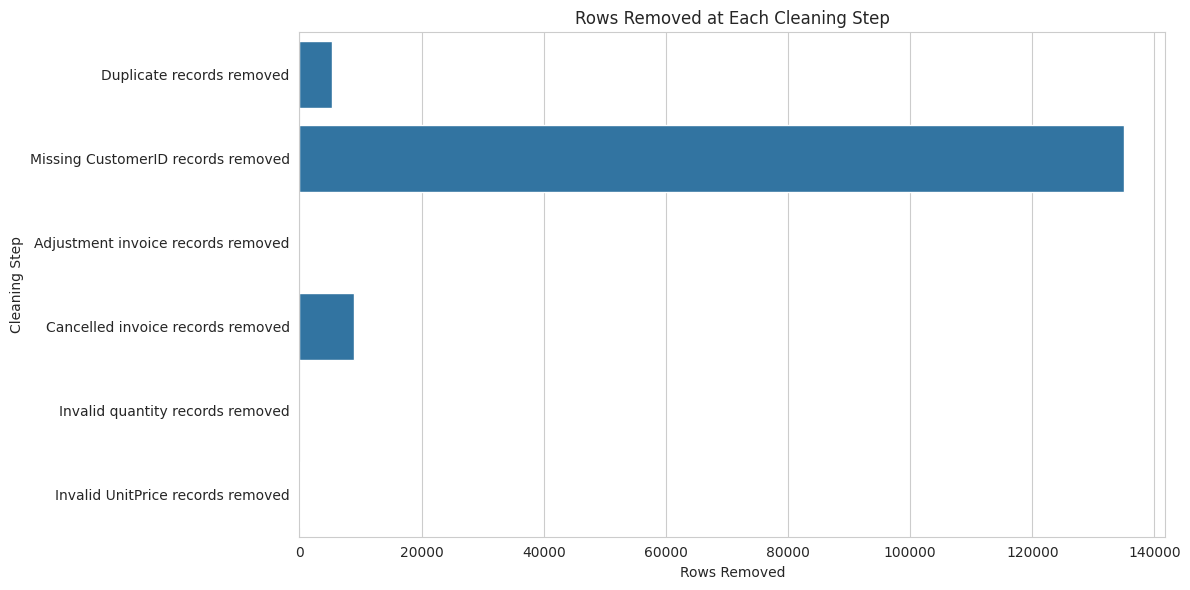

In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=cleaning_summary,
    x="Rows Removed",
    y="Cleaning Step"
)
plt.title("Rows Removed at Each Cleaning Step")
plt.xlabel("Rows Removed")
plt.ylabel("Cleaning Step")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "cleaning_summary_rows_removed.png"), dpi=300)
plt.show()


## 16. Visualise numerical distributions and outliers



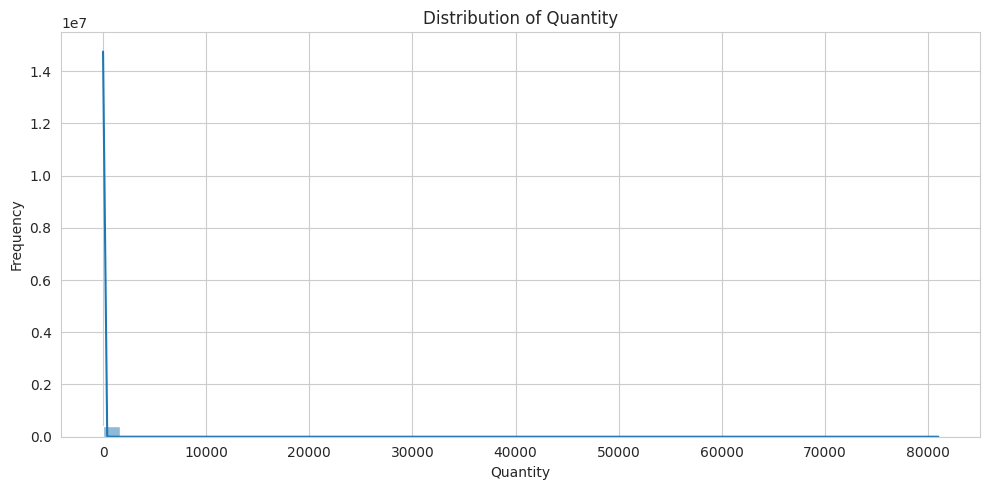

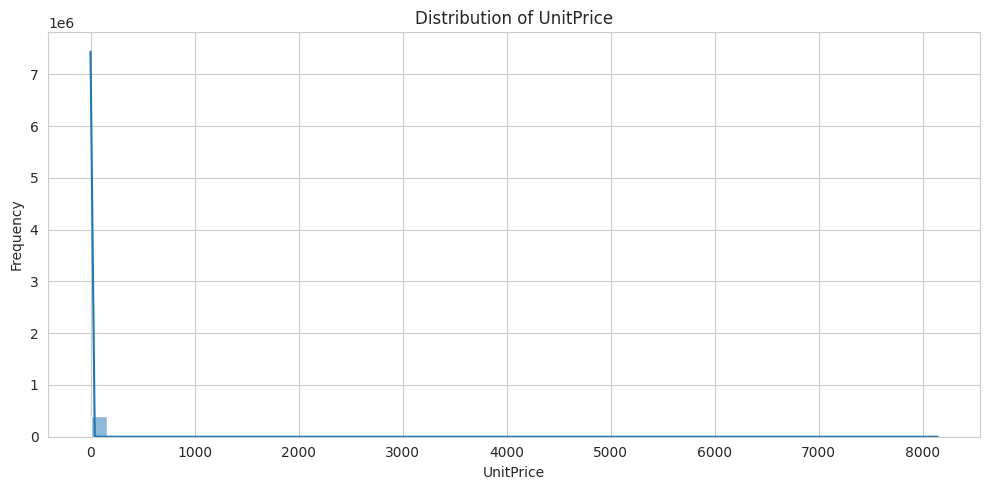

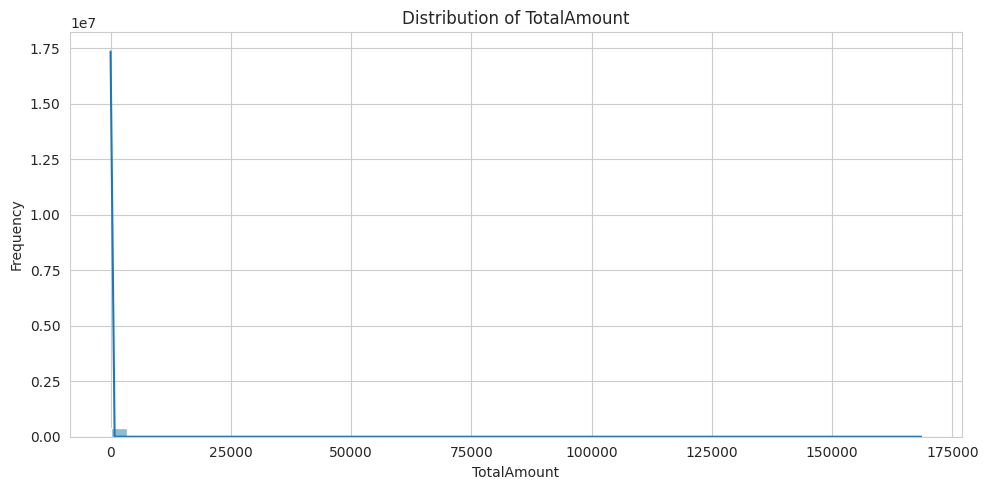

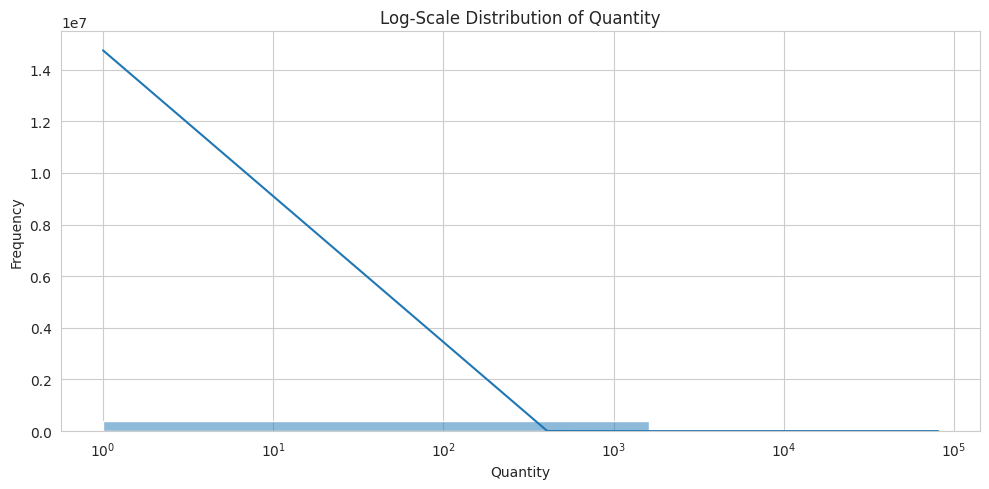

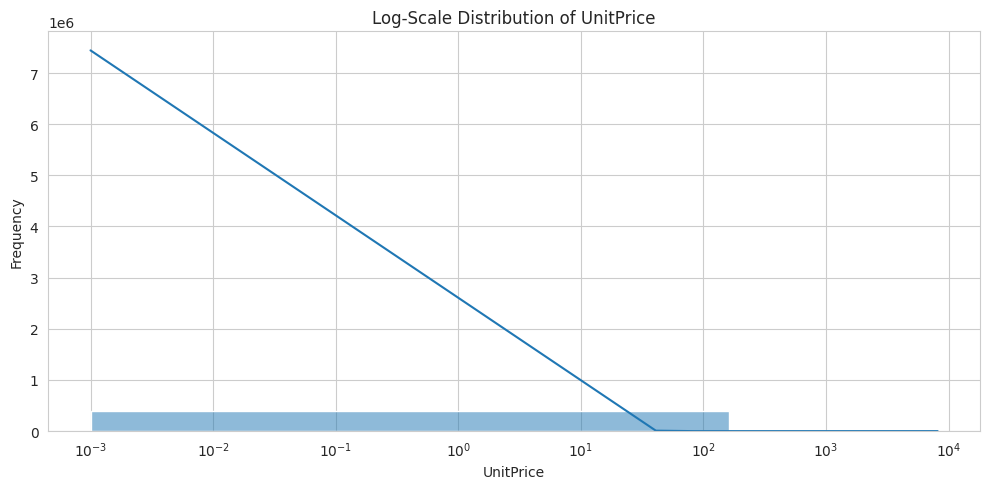

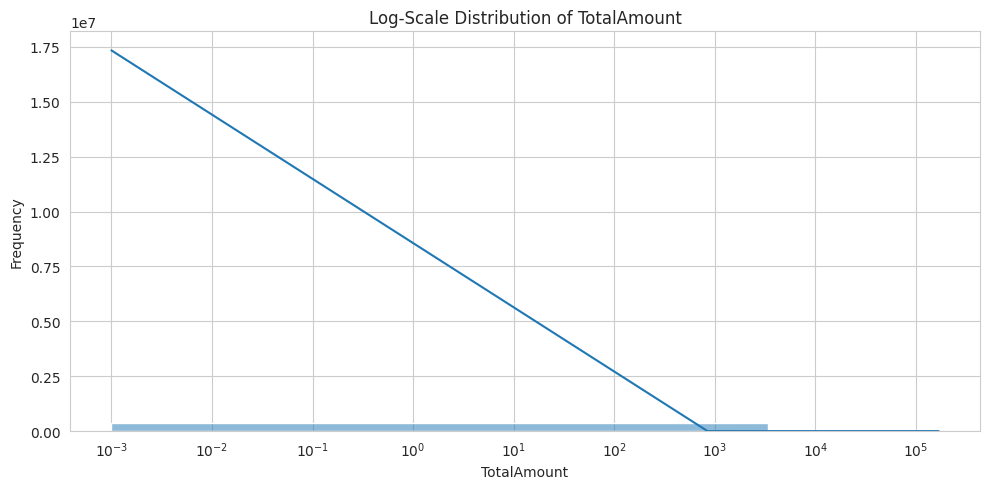

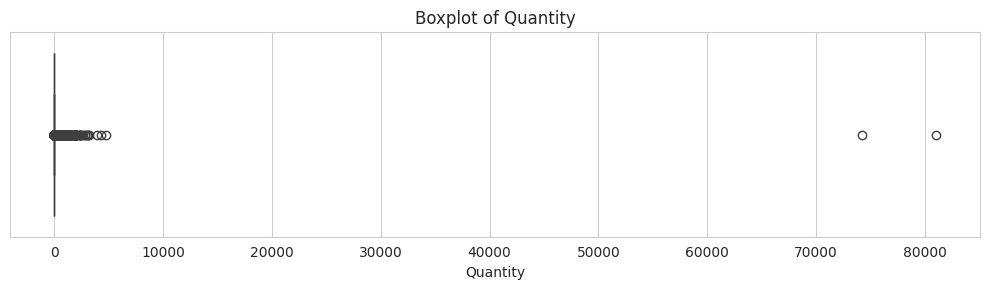

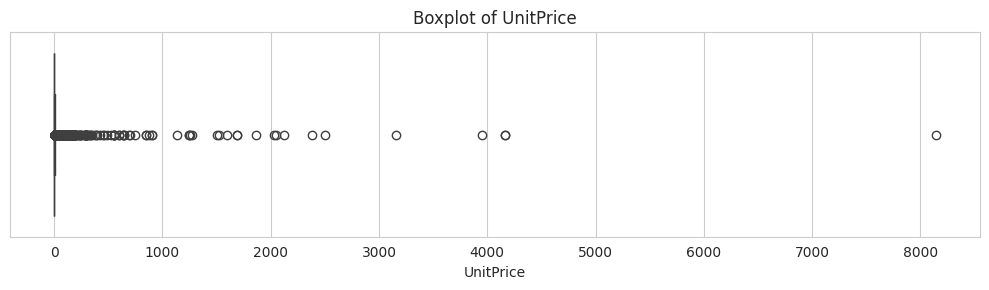

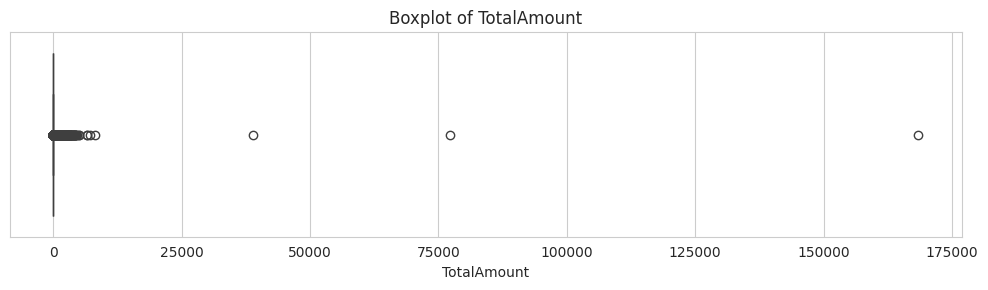

In [17]:
for col in numeric_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, f"{col}_distribution.png"), dpi=300)
    plt.show()

# VISUALISATIONS: LOG-SCALE DISTRIBUTIONS

for col in numeric_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], bins=50, kde=True)
    plt.xscale("log")
    plt.title(f"Log-Scale Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, f"{col}_log_scale_distribution.png"), dpi=300)
    plt.show()

#VISUALISATIONS: BOXPLOTS

for col in numeric_cols:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, f"{col}_boxplot.png"), dpi=300)
    plt.show()


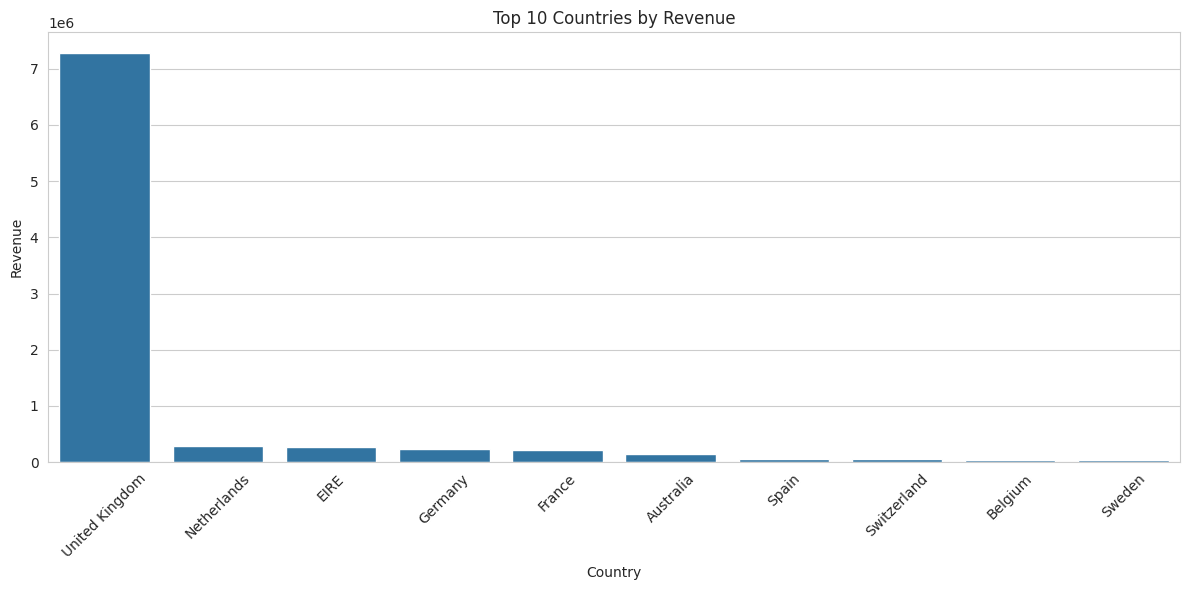

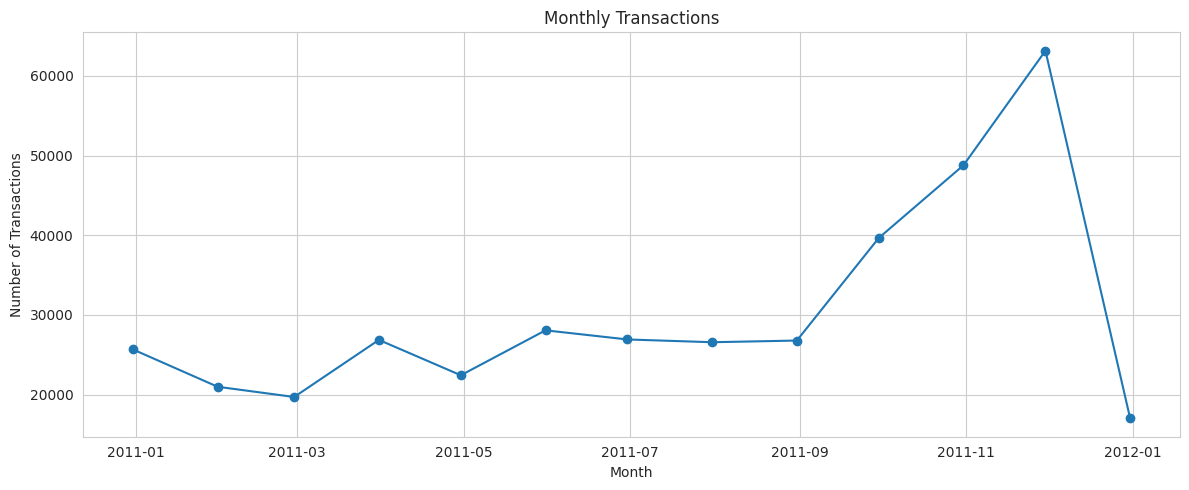

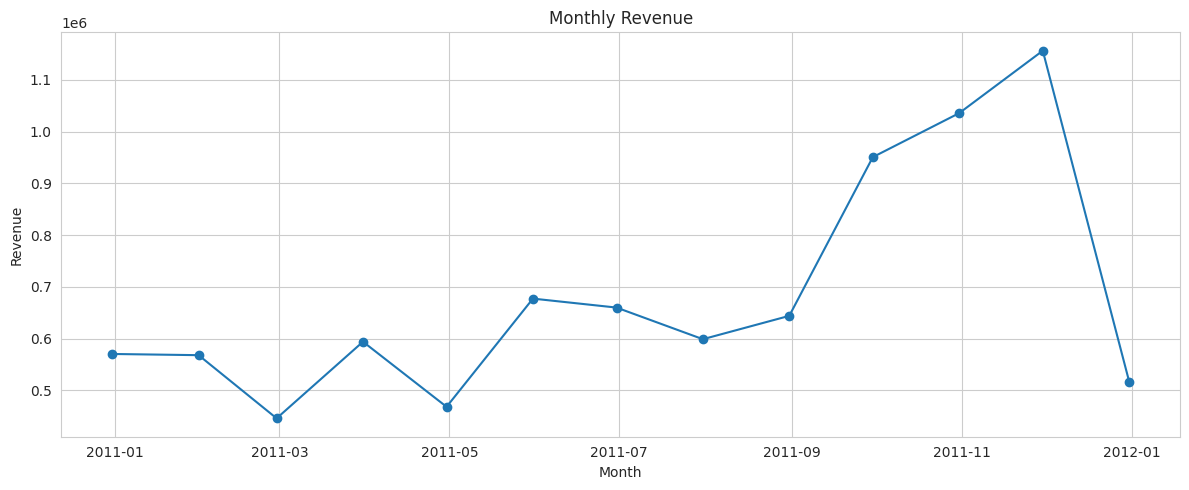

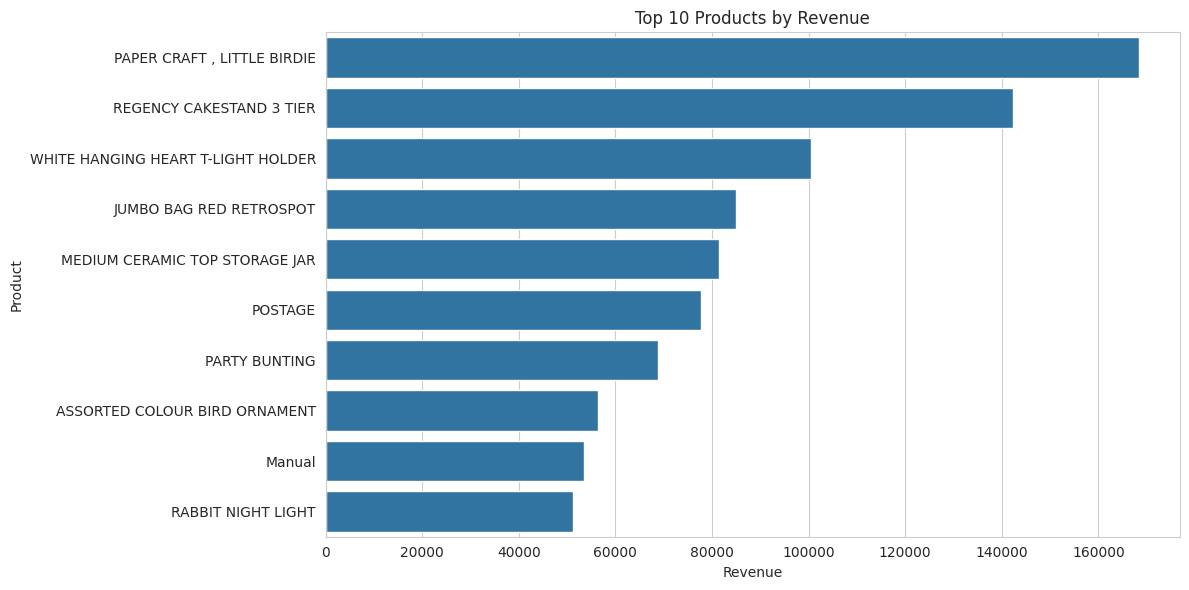

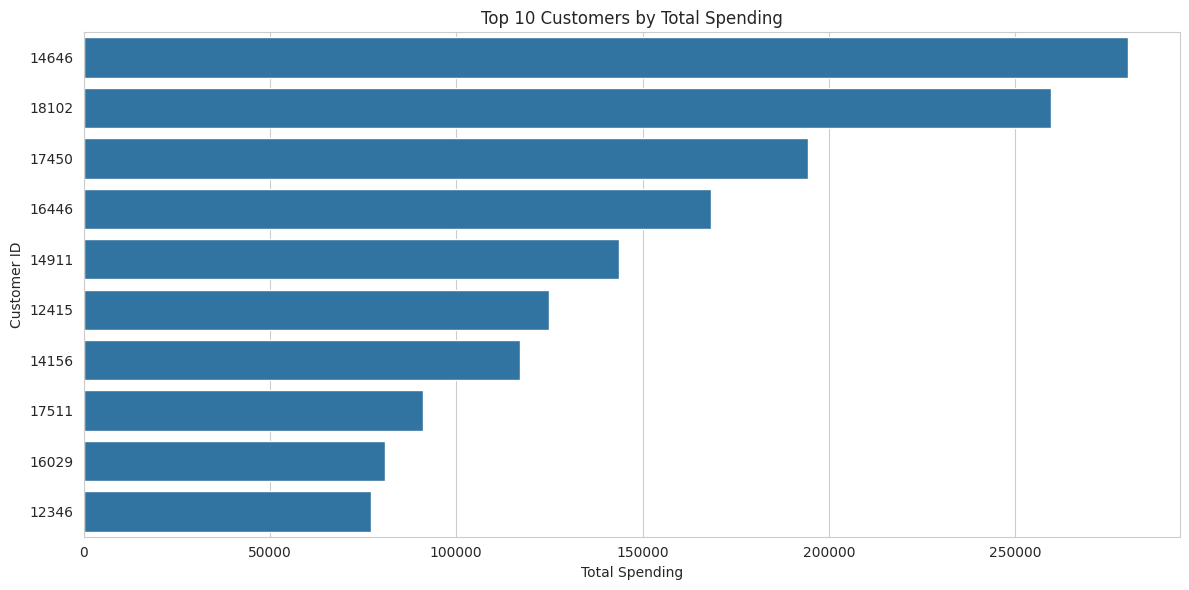

In [18]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=country_summary.head(10).index,
    y=country_summary.head(10)["Revenue"]
)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "top_10_countries_by_revenue.png"), dpi=300)
plt.show()

#VISUALISATIONS: MONTHLY TRANSACTIONS

plt.figure(figsize=(12, 5))
plt.plot(monthly_summary.index, monthly_summary["Transactions"], marker="o")
plt.title("Monthly Transactions")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "monthly_transactions.png"), dpi=300)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly_summary.index, monthly_summary["Revenue"], marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "monthly_revenue.png"), dpi=300)
plt.show()

#TOP PRODUCTS

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_products.head(10)["Revenue"],
    y=[str(idx[1]) for idx in top_products.head(10).index]
)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "top_10_products_by_revenue.png"), dpi=300)
plt.show()

# TOP CUSTOMERS

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_customers.head(10)["TotalSpent"],
    y=top_customers.head(10).index.astype(str)
)
plt.title("Top 10 Customers by Total Spending")
plt.xlabel("Total Spending")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "top_10_customers_by_spending.png"), dpi=300)
plt.show()


## 18. Run the final quality report and export the cleaned data

This is the final checkpoint before moving to customer-level feature engineering(**RFM**)



In [19]:
final_quality_report = pd.DataFrame({
    "Metric": [
        "Ready for RFM Feature Engineering",
        "Missing Values Remaining",
        "Duplicate Records Remaining",
        "Invalid Quantity Remaining",
        "Invalid UnitPrice Remaining",
        "Invalid TotalAmount Remaining",
        "Cancelled Invoices Remaining",
        "Adjustment Invoices Remaining",
        "Final Dataset Shape"
    ],
    "Result": [
        "YES",
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        (df["Quantity"] <= 0).sum(),
        (df["UnitPrice"] <= 0).sum(),
        (df["TotalAmount"] <= 0).sum(),
        df["InvoiceNo"].astype(str).str.startswith("C").sum(),
        df["InvoiceNo"].astype(str).str.startswith("A").sum(),
        str(df.shape)
    ]
})

display(final_quality_report)

final_quality_report.to_csv(
    os.path.join(tables_dir, "final_quality_report.csv"),
    index=False
)

# EXPORTING CLEANED DATASET READY FOR RFM

cleaned_data_path = os.path.join(data_dir, "cleaned_online_retail_ready_for_rfm.csv")

df.to_csv(cleaned_data_path, index=False)

print("=" * 80)
print("DATA CLEANING COMPLETED SUCCESSFULLY")
print("Cleaned dataset saved at:", cleaned_data_path)
print("Dataset is ready for RFM Feature Engineering")
print("=" * 80)


,Metric,Result
0,Ready for RFM Feature Engineering,YES
1,Missing Values Remaining,0
2,Duplicate Records Remaining,0
3,Invalid Quantity Remaining,0
4,Invalid UnitPrice Remaining,0
5,Invalid TotalAmount Remaining,0
6,Cancelled Invoices Remaining,0
7,Adjustment Invoices Remaining,0
8,Final Dataset Shape,"(392692, 9)"


DATA CLEANING COMPLETED SUCCESSFULLY
Cleaned dataset saved at: Results/Data/cleaned_online_retail_ready_for_rfm.csv
Dataset is ready for RFM Feature Engineering


## 19. Independent final dataset check


In [20]:
print("="*60)
print("FINAL DATASET CHECK")
print("="*60)

df.info()

print("\nDataset Shape")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

print("\nUnique Customers")
print(df["CustomerID"].nunique())

print("\nUnique Invoices")
print(df["InvoiceNo"].nunique())

print("\nDate Range")
print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())


FINAL DATASET CHECK
<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
 8   TotalAmount  392692 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.0+ MB

Dataset Shape
(392692, 9)

Missing Values
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

Duplicate Records
0

Unique Custo